In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lace.cosmo import cosmology
import camb

In [11]:
hubble, z = 0.71, 2.5
omegab, omegam = 0.046, 0.27
omegal = 1 - omegam
omegac = omegam - omegab
ns = 0.96
As = 2.1e-9

# MW11

In [12]:
pars = camb.set_params(H0=100*hubble, ombh2=omegab*(hubble**2), omch2=omegac*(hubble**2), ns=ns, As=As)
pars.set_matter_power(redshifts=[z], kmax=100)
results = camb.get_results(pars)
k_lin, z, pk = results.get_linear_matter_power_spectrum(hubble_units=False, k_hunit=False)

# Cupix

In [13]:
cosmo_dict = {
    'H0': 100*hubble,
    'ombh2': omegab*hubble**2,
    'omch2': omegac*hubble**2,
    'ns': ns,
    'As': As}

In [14]:
cosmo = cosmology.Cosmology(cosmo_params_dict=cosmo_dict)
#cosmo.CAMBparams.set_cosmology(H0=hubble*100, ombh2=omegab*(hubble**2), omch2=omegac*(hubble**2), n_s=ns)
linP = cosmo.get_linP_Mpc(z, k_lin)

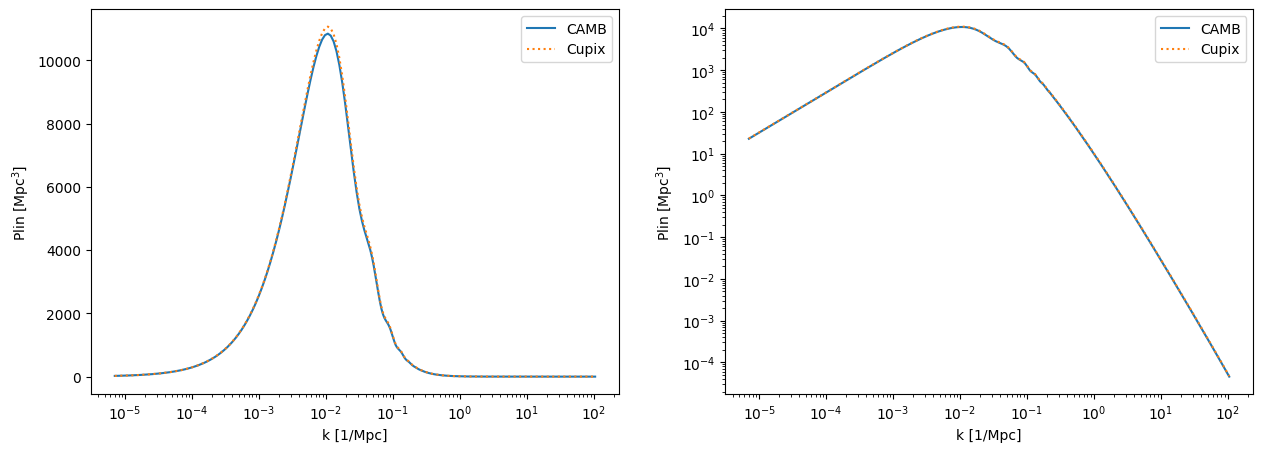

In [15]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_lin, pk[0, :], label='CAMB')
plt.plot(k_lin, linP[0, :], linestyle=':', label='Cupix')
plt.xscale('log')
plt.xlabel('k [1/Mpc]')
plt.ylabel(r'Plin [Mpc$^3$]')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(k_lin, pk[0, :], label='CAMB')
plt.plot(k_lin, linP[0, :], linestyle=':', label='Cupix')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('k [1/Mpc]')
plt.ylabel(r'Plin [Mpc$^3$]')
plt.legend()

Now much better

# Which one was failing?

In [16]:
pars = camb.set_params(H0=100*hubble, ombh2=omegab*(hubble**2), omch2=omegac*(hubble**2), ns=ns)
pars.set_matter_power(redshifts=[z], kmax=100)
results = camb.get_results(pars)
k_lin1, z, pk1 = results.get_linear_matter_power_spectrum(hubble_units=False, k_hunit=False)

pars = camb.set_params(H0=100*hubble, ombh2=omegab*(hubble**2), omch2=omegac*(hubble**2), ns=ns, As=As)
pars.set_matter_power(redshifts=[z], kmax=100)
results = camb.get_results(pars)
k_lin2, z, pk2 = results.get_linear_matter_power_spectrum(hubble_units=False, k_hunit=False)

In [19]:
cosmo_dict1 = {
    'H0': 100*hubble,
    'ombh2': omegab*hubble**2,
    'omch2': omegac*hubble**2,
    'ns': ns}

cosmo_dict2 = {
    'H0': 100*hubble,
    'ombh2': omegab*hubble**2,
    'omch2': omegac*hubble**2,
    'ns': ns,
    'As': As}

cosmo = cosmology.Cosmology(cosmo_params_dict=cosmo_dict1)
linP1 = cosmo.get_linP_Mpc(z, k_lin1)
cosmo = cosmology.Cosmology(cosmo_params_dict=cosmo_dict2)
linP2 = cosmo.get_linP_Mpc(z, k_lin2)

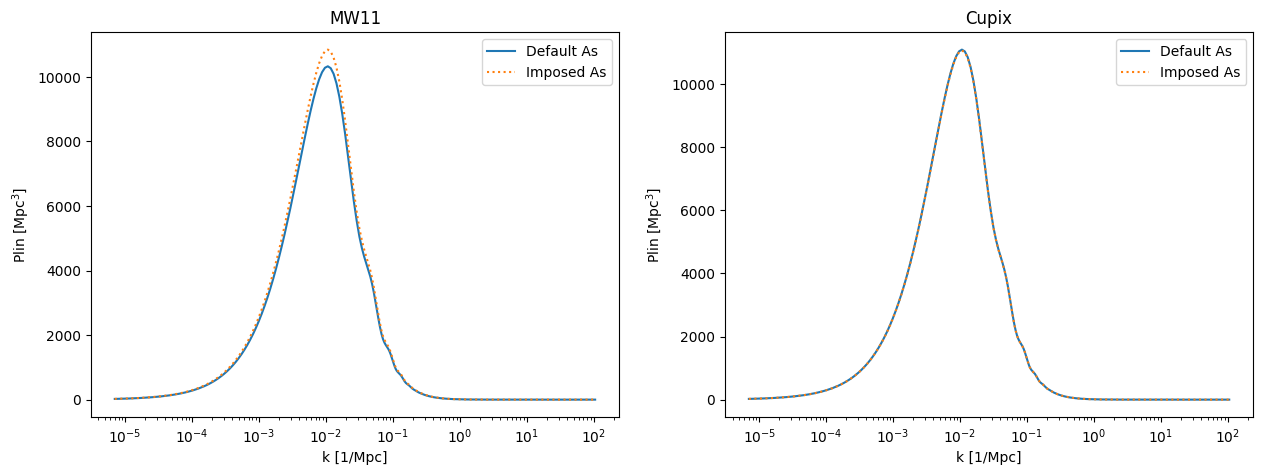

In [21]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title('MW11')
plt.plot(k_lin1, pk1[0, :], label='Default As')
plt.plot(k_lin2, pk2[0, :], linestyle=':', label='Imposed As')
plt.xscale('log')
plt.xlabel('k [1/Mpc]')
plt.ylabel(r'Plin [Mpc$^3$]')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Cupix')
plt.plot(k_lin1, linP1[0, :], label='Default As')
plt.plot(k_lin2, linP2[0, :], linestyle=':', label='Imposed As')
plt.xscale('log')
plt.xlabel('k [1/Mpc]')
plt.ylabel(r'Plin [Mpc$^3$]')
plt.legend();